
# MARL Q-Net Policy Record Analysis

Use this notebook to load the policy-record experiments (generated by
`experiments/n_player_experiments_policy_record.py`), visualise aggregate
market metrics, and inspect the policy probe action shares that are now
embedded directly in the episode summaries.


In [1]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'analysis' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from analysis.analysis_utils import (
    load_experiment,
    runs_to_frame,
    plot_metric_over_episodes,
    plot_action_family_shares,
    DEFAULT_ACTION_FAMILIES,
)

DATA_DIR = NOTEBOOK_DIR / 'results'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

target_res = 'n_player_market_composition_carryover_policy_record_N5_lambda1_rho1-0.9-0.5-0.1-0_20251111T022914Z'
TARGET_FIG_DIR = FIG_DIR / target_res
TARGET_FIG_DIR.mkdir(exist_ok=True)

sorted(DATA_DIR.glob('*.json'))[:3]

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:

experiment_payload = load_experiment(DATA_DIR / f"{target_res}.json")
episode_frame = runs_to_frame(experiment_payload)
print(f"Loaded {len(episode_frame):,} episode rows from {target_res}.json")
episode_frame.head()


Loaded 7,500,000 episode rows from n_player_market_composition_carryover_policy_record_N5_lambda1_rho1-0.9-0.5-0.1-0_20251111T022914Z.json


,scenario,share_parameters,seed,episode,mean_profit,avg_price,avg_lowest_price,repricer_share,action_share_no_repricer,action_share_undercut,...,policy_probe_near_marginal_cost_share_undercut_reset,policy_probe_near_marginal_cost_share_undercut_reset_raise,policy_probe_near_marginal_cost_share_match,policy_probe_near_marginal_cost_share_match_raise,policy_probe_near_marginal_cost_share_match_reset,policy_probe_near_marginal_cost_share_match_reset_raise,policy_probe_near_marginal_cost_share_above,policy_probe_near_marginal_cost_share_above_raise,policy_probe_near_marginal_cost_share_above_reset,policy_probe_near_marginal_cost_share_above_reset_raise
0,rho_0,False,0,0.0,0.051140,2.544130,2.299375,1.0,0.0,0.0,...,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.0
1,rho_0,False,0,1.0,0.018980,2.176165,2.091250,1.0,0.0,0.2,...,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.0
2,rho_0,False,0,2.0,0.020440,2.174500,2.091250,1.0,0.0,0.0,...,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.0
3,rho_0,False,0,3.0,0.017885,3.336670,2.091250,0.6,0.4,0.2,...,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.0
4,rho_0,False,0,4.0,0.020805,2.267740,2.091250,0.8,0.2,0.0,...,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.0


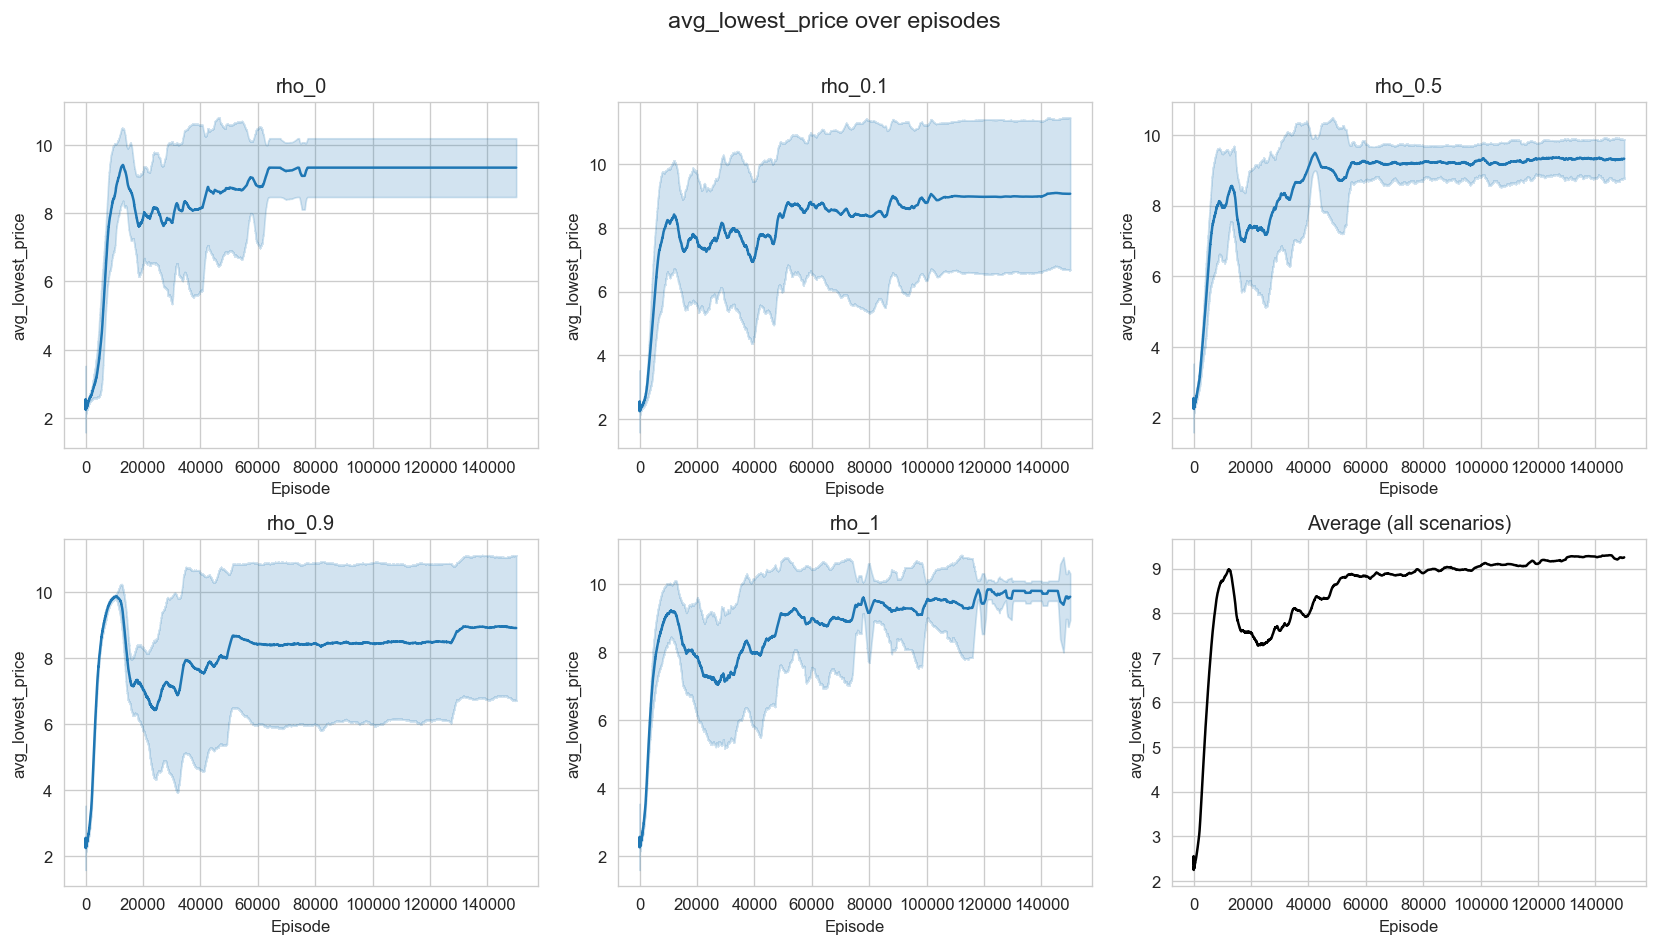

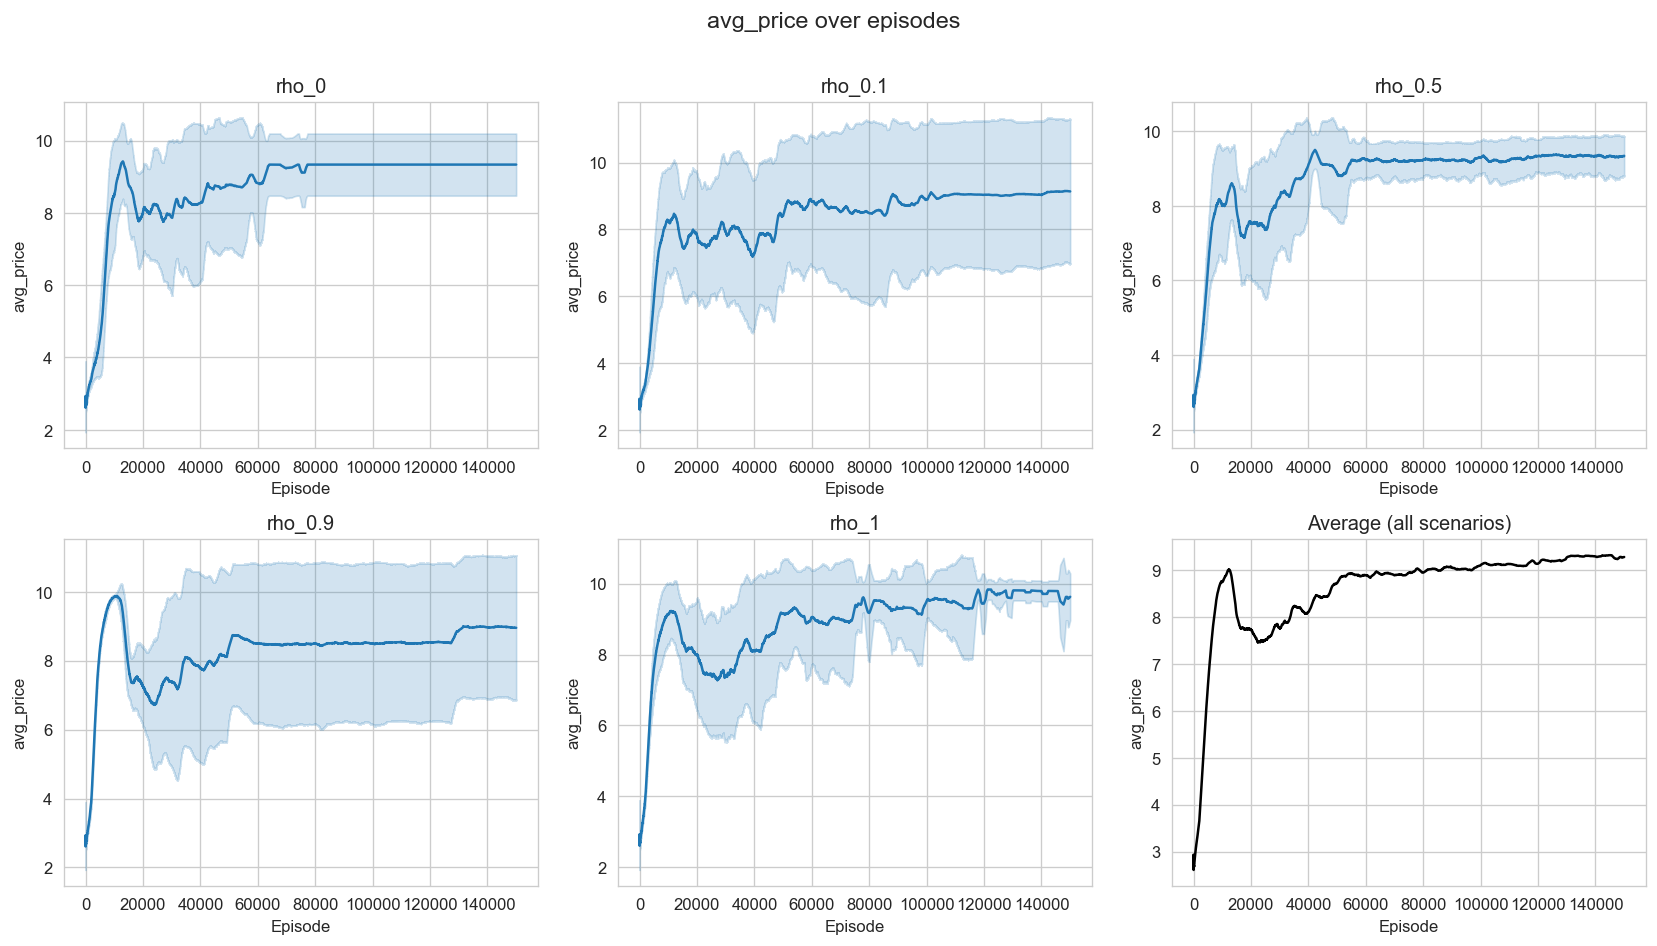

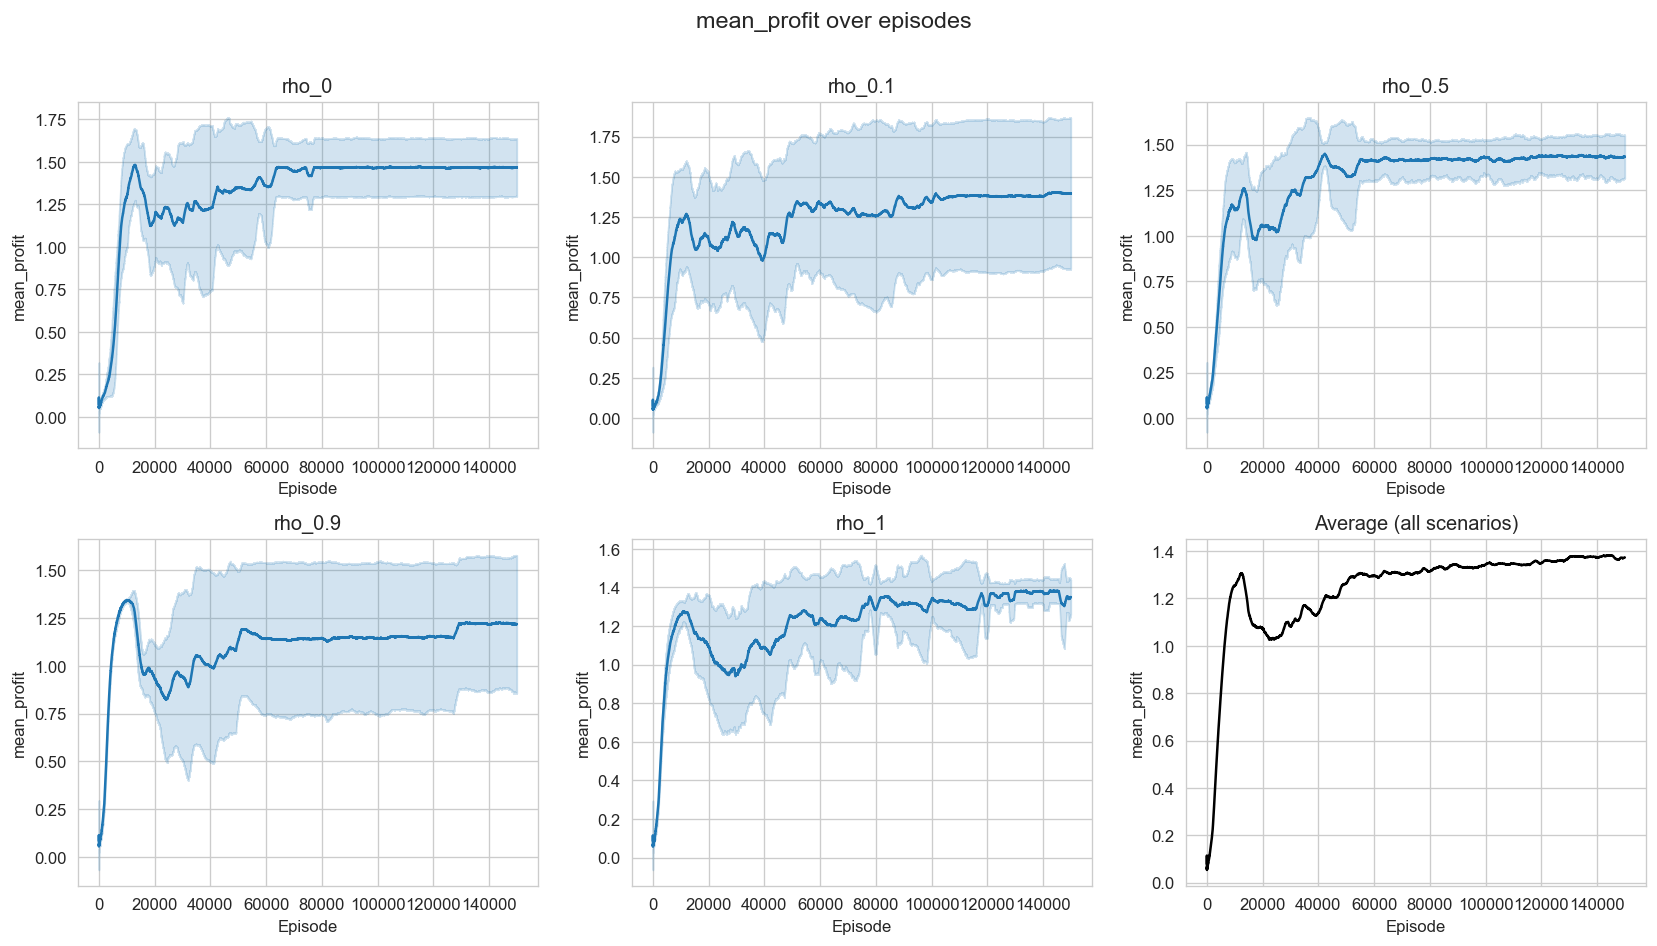

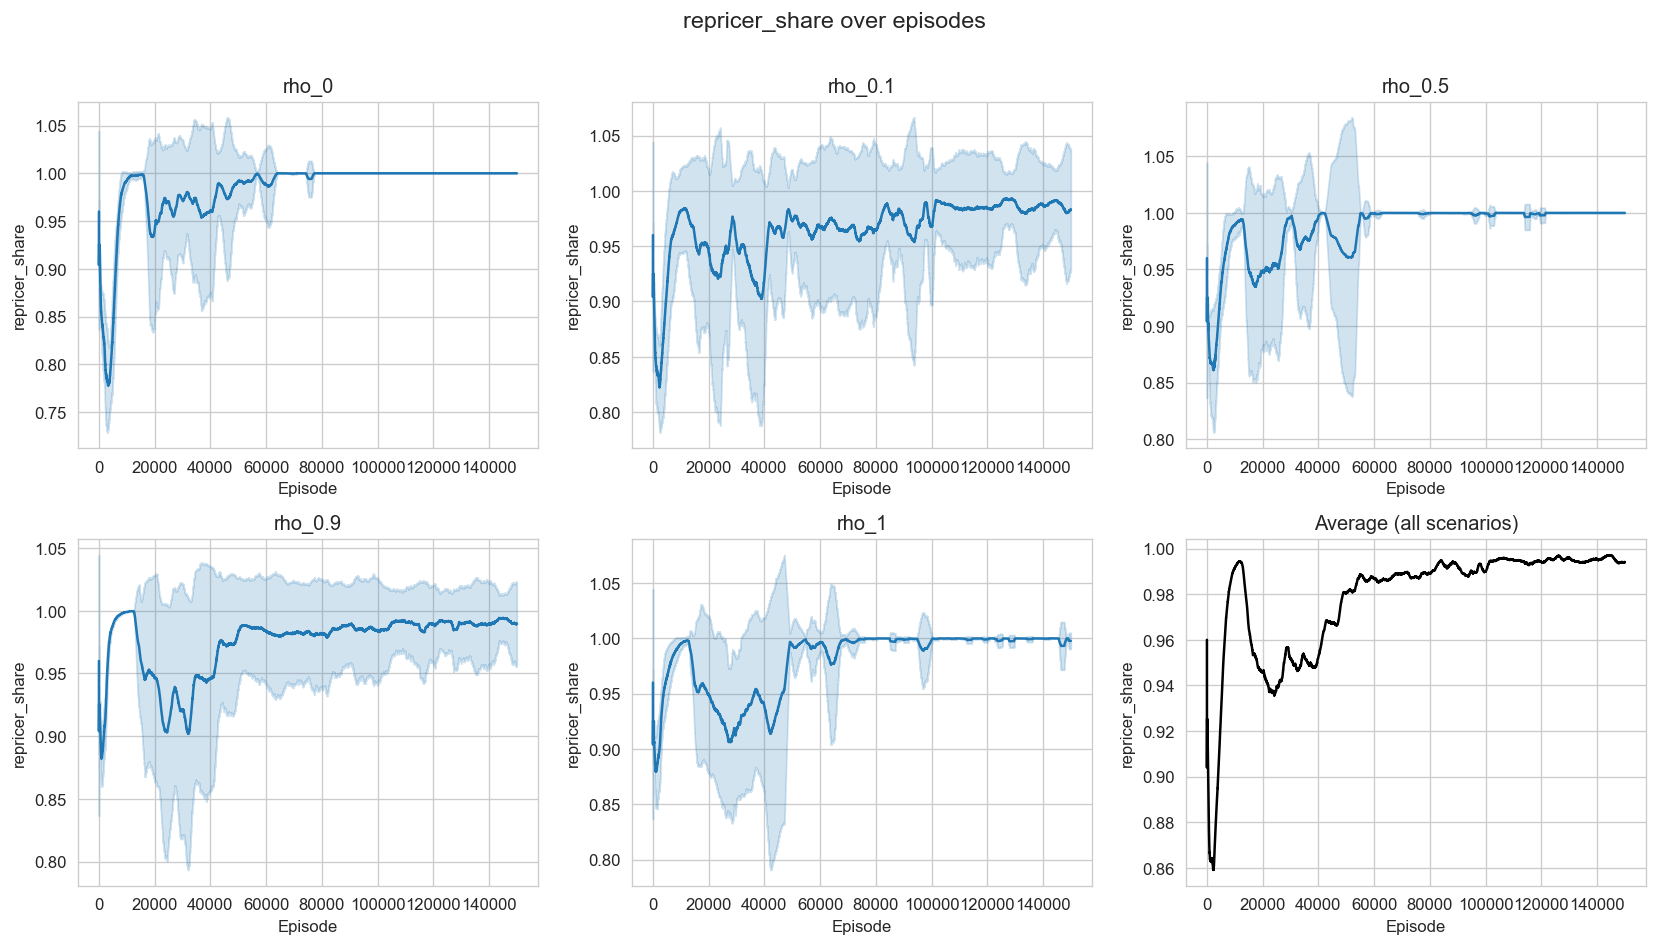

In [3]:

METRICS_TO_PLOT = ["avg_lowest_price", "avg_price", "mean_profit", "repricer_share"]
SMOOTHING = 2000

for metric in METRICS_TO_PLOT:
    plot_metric_over_episodes(
        episode_frame,
        metric,
        smoothing=SMOOTHING,
        layout=(2, 3),
        title=f"{metric} over episodes",
    )


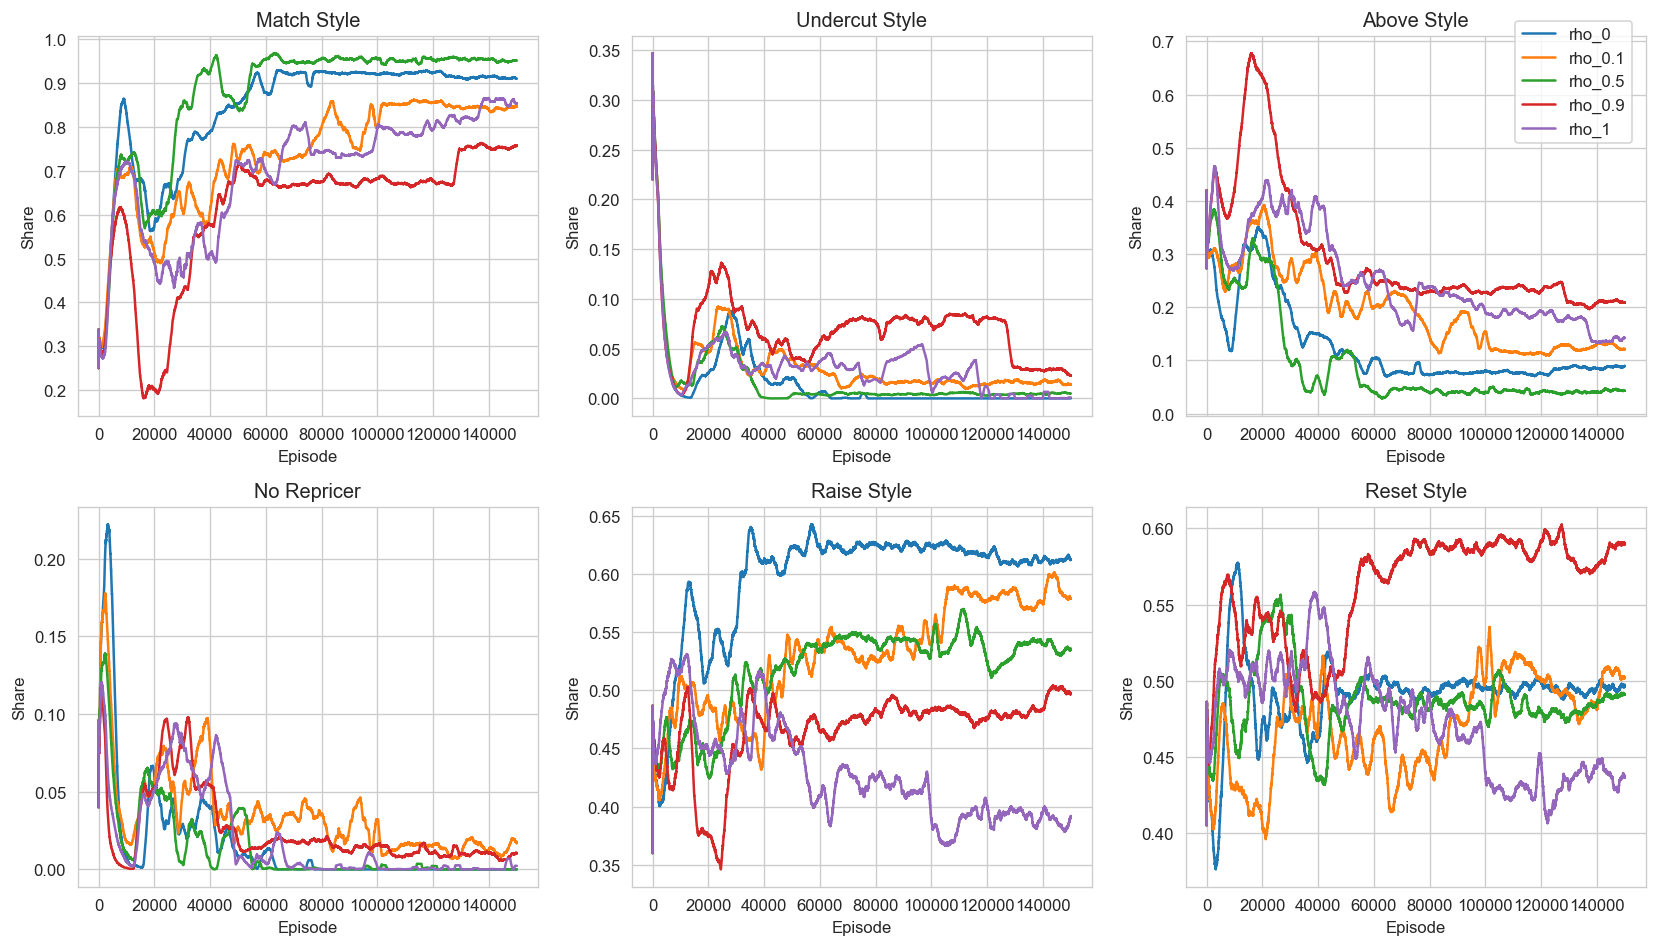

In [4]:

plot_action_family_shares(
    episode_frame,
    smoothing=2000,
    layout=(2, 3),
    figsize=(14, 8),
)


In [5]:

def extract_probe_action_shares(frame: pd.DataFrame) -> pd.DataFrame:
    prefix = "policy_probe_"
    probe_cols = [col for col in frame.columns if col.startswith(prefix) and "_share_" in col]
    if not probe_cols:
        return pd.DataFrame()
    required_cols = ["scenario", "seed", "episode"]
    missing = [col for col in required_cols if col not in frame.columns]
    if missing:
        raise ValueError(f"Episode frame missing required columns: {missing}")
    subset = frame[required_cols + probe_cols].copy()
    melted = subset.melt(id_vars=required_cols, value_vars=probe_cols, var_name="probe_action", value_name="share")
    melted["share"] = melted["share"].fillna(0.0)
    parts = (
        melted["probe_action"].str[len(prefix):]
        .str.split("_share_", n=1, expand=True)
    )
    melted["probe"] = parts[0]
    melted["action"] = parts[1]
    melted.drop(columns=["probe_action"], inplace=True)
    return melted

probe_action_frame = extract_probe_action_shares(episode_frame)

if probe_action_frame.empty:
    print("No policy probe action-share columns found in this result file.")
else:
    print(f"Probe-action rows: {len(probe_action_frame):,}")
    display(probe_action_frame.head())


Probe-action rows: 97,500,000


,scenario,seed,episode,share,probe,action
0,rho_0,0,0.0,0.0,near_marginal_cost,no_repricer
1,rho_0,0,1.0,0.0,near_marginal_cost,no_repricer
2,rho_0,0,2.0,0.0,near_marginal_cost,no_repricer
3,rho_0,0,3.0,0.0,near_marginal_cost,no_repricer
4,rho_0,0,4.0,0.0,near_marginal_cost,no_repricer


In [6]:

def plot_probe_action_shares(action_df: pd.DataFrame, probe_label: str, *, smoothing: int = 2000, max_actions: int = 6, layout: tuple[int, int] = (2, 3)) -> None:
    subset = action_df[action_df["probe"] == probe_label].copy()
    if subset.empty:
        print(f"No data for probe '{probe_label}'.")
        return
    if smoothing > 1:
        subset["share"] = (
            subset.groupby(["scenario", "seed", "action"])["share"]
            .transform(lambda x: x.rolling(window=smoothing, min_periods=1).mean())
        )
    mean_shares = (
        subset.groupby("action", as_index=False)["share"]
        .mean(numeric_only=True)
        .sort_values("share", ascending=False)
    )
    top_actions = mean_shares.head(max_actions)["action"].tolist()
    subset = subset[subset["action"].isin(top_actions)].copy()

    rows, cols = layout
    total_axes = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
    axes_list = axes.flatten() if total_axes > 1 else [axes]

    for idx, action in enumerate(top_actions):
        if idx >= total_axes:
            break
        ax = axes_list[idx]
        action_df = (
            subset[subset["action"] == action]
            .groupby(["scenario", "episode"], as_index=False)["share"]
            .mean(numeric_only=True)
        )
        for scenario in sorted(action_df["scenario"].unique()):
            scenario_df = action_df[action_df["scenario"] == scenario]
            ax.plot(scenario_df["episode"], scenario_df["share"], label=scenario)
        ax.set_title(action)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Share")

    for idx in range(len(top_actions), total_axes):
        axes_list[idx].set_visible(False)

    handles, labels = axes_list[0].get_legend_handles_labels()
    if labels:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(f"Top action shares for probe '{probe_label}'", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [7]:

def build_probe_family_frame(action_df: pd.DataFrame, family_rules=None) -> pd.DataFrame:
    if action_df.empty:
        return pd.DataFrame()
    rules = family_rules or DEFAULT_ACTION_FAMILIES
    frames = []
    for family, predicate in rules.items():
        mask = action_df["action"].apply(predicate)
        if not mask.any():
            continue
        fam_df = (
            action_df[mask]
            .groupby(["scenario", "seed", "episode", "probe"], as_index=False)["share"]
            .sum(numeric_only=True)
        )
        fam_df["family"] = family
        frames.append(fam_df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

probe_family_frame = build_probe_family_frame(probe_action_frame)
if probe_family_frame.empty:
    print("No probe family data available.")
else:
    display(probe_family_frame.head())


,scenario,seed,episode,probe,share,family
0,rho_0,0,0.0,near_marginal_cost,0.0,Match Style
1,rho_0,0,1.0,near_marginal_cost,0.0,Match Style
2,rho_0,0,2.0,near_marginal_cost,0.0,Match Style
3,rho_0,0,3.0,near_marginal_cost,0.0,Match Style
4,rho_0,0,4.0,near_marginal_cost,0.0,Match Style


In [8]:

def plot_probe_family_shares(frame: pd.DataFrame, probe_label: str, *, smoothing: int = 2000, layout: tuple[int, int] = (2, 3)) -> None:
    subset = frame[frame["probe"] == probe_label].copy()
    if subset.empty:
        print(f"No family data for probe '{probe_label}'.")
        return
    if smoothing > 1:
        subset["share"] = (
            subset.groupby(["scenario", "seed", "family"])["share"]
            .transform(lambda x: x.rolling(window=smoothing, min_periods=1).mean())
        )
    families = list(dict.fromkeys(subset["family"]))
    rows, cols = layout
    total_axes = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
    axes_list = axes.flatten() if total_axes > 1 else [axes]

    for idx, family in enumerate(families):
        if idx >= total_axes:
            break
        ax = axes_list[idx]
        fam_df = (
            subset[subset["family"] == family]
            .groupby(["scenario", "episode"], as_index=False)["share"]
            .mean(numeric_only=True)
        )
        for scenario in sorted(fam_df["scenario"].unique()):
            scenario_df = fam_df[fam_df["scenario"] == scenario]
            ax.plot(scenario_df["episode"], scenario_df["share"], label=scenario)
        ax.set_title(family)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Share")

    for idx in range(len(families), total_axes):
        axes_list[idx].set_visible(False)

    handles, labels = axes_list[0].get_legend_handles_labels()
    if labels:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(f"Action-family shares for probe '{probe_label}'", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


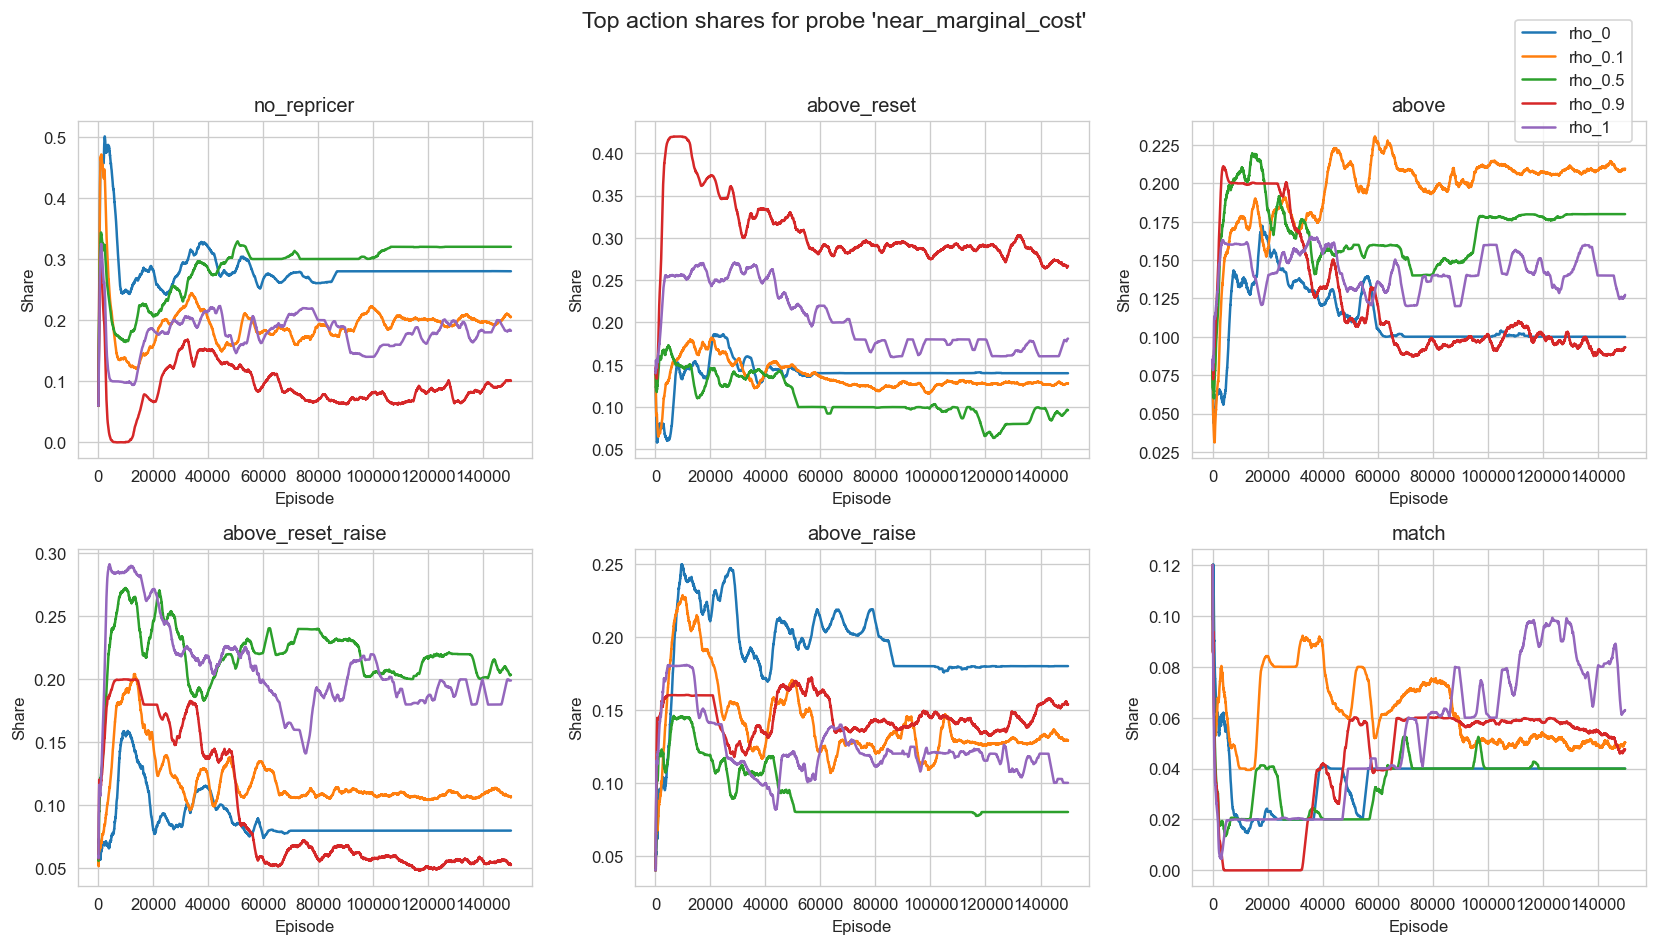

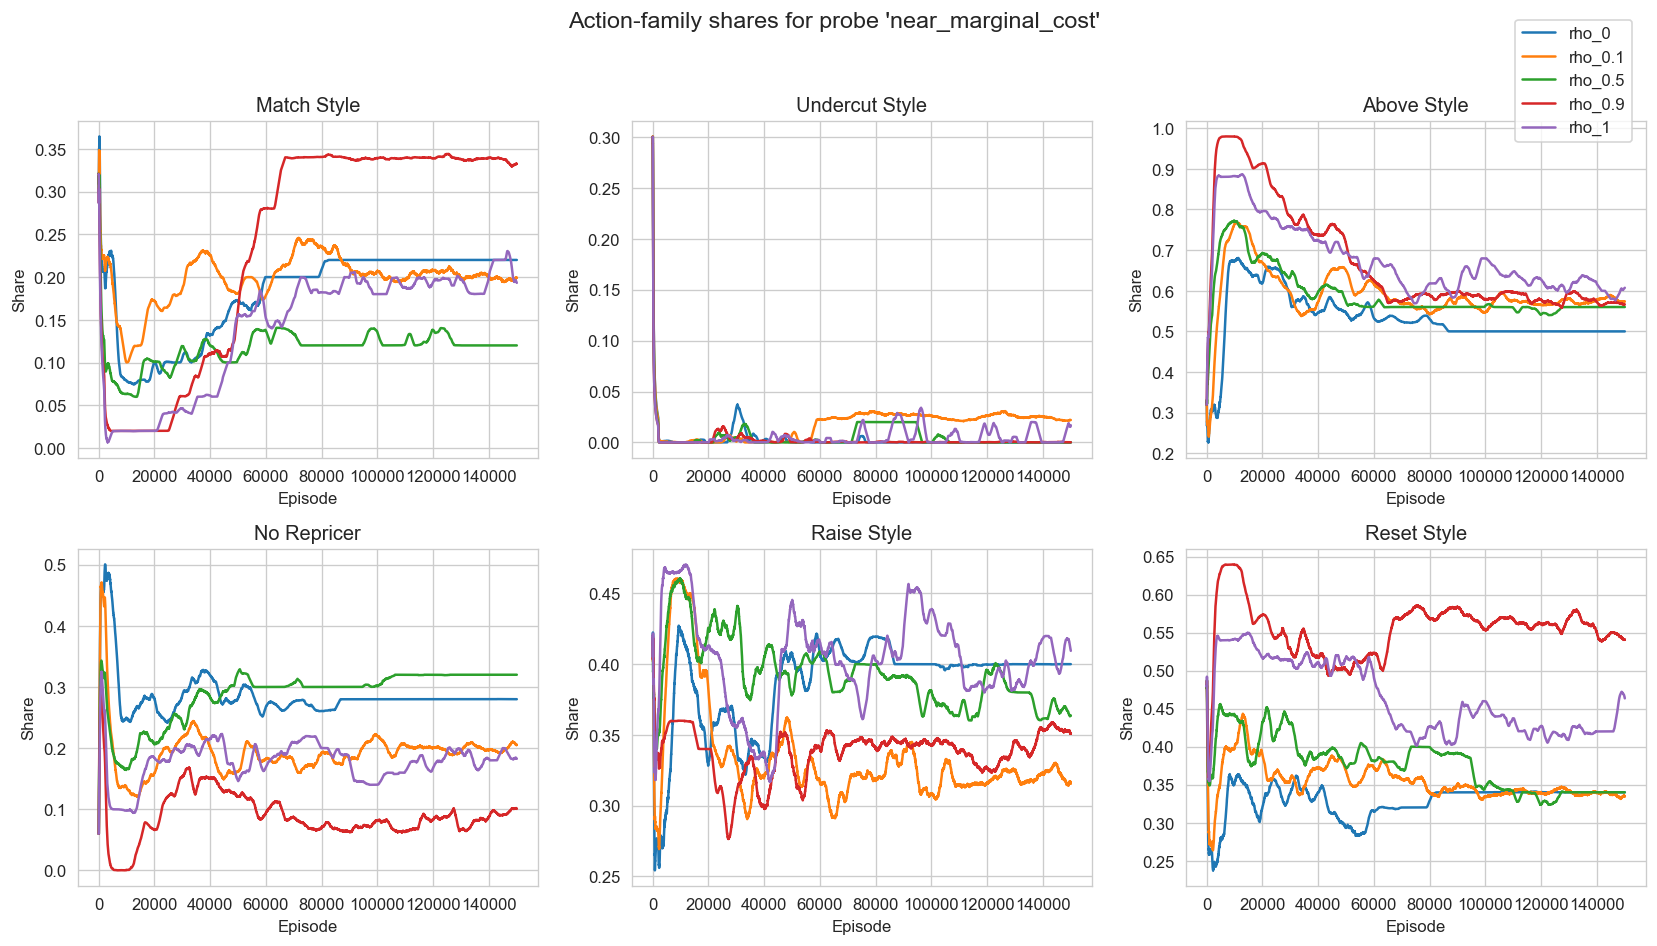

In [9]:

if not probe_action_frame.empty:
    for probe_name in sorted(probe_action_frame["probe"].unique()):
        plot_probe_action_shares(probe_action_frame, probe_name)
else:
    print("Skipping probe action plots; no probe data available.")

if not probe_family_frame.empty:
    for probe_name in sorted(probe_family_frame["probe"].unique()):
        plot_probe_family_shares(probe_family_frame, probe_name)
else:
    print("Skipping probe family plots; no probe data available.")


In [2]:
import numpy as np
price_min = 0.01
price_max = 10.0
grid_size = 25

price_grid = np.linspace(price_min, price_max, grid_size)
print(price_grid)

[ 0.01     0.42625  0.8425   1.25875  1.675    2.09125  2.5075   2.92375
  3.34     3.75625  4.1725   4.58875  5.005    5.42125  5.8375   6.25375
  6.67     7.08625  7.5025   7.91875  8.335    8.75125  9.1675   9.58375
 10.     ]


In [7]:
grid = np.linspace(0.5, 10.0, 20)
# 避免浮点微小误差（可选）
# grid = np.round(grid, 2)

print(grid)

[ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10. ]
